 # Exploratory Data Analysis for KIS power grid outages

## Importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from datetime import timedelta

## Data collection

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/Phionanamugga/POWER_GRID_AI_PREDICITIVE_MAINTENANCE/refs/heads/feature1/poweroutage2024final.csv')

In [5]:
# Setting plot style
sns.set(style="whitegrid")

## Checking data properties

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   STARTDATEANDTIME  250 non-null    object
 1   ENDDATEANDTIME    250 non-null    object
 2   DURATION          250 non-null    object
dtypes: object(3)
memory usage: 6.0+ KB


In [7]:
df.head()

,STARTDATEANDTIME,ENDDATEANDTIME,DURATION
0,02/01/2024 15:51,02/01/2024 15:52,00:24
1,06/01/2024 14:58,06/01/2024 15:01,00:03
2,08/01/2024 14:29,08/01/2024 14:30,00:01
3,12/01/2024 08:45,12/01/2024 08:46,00:01
4,16/01/2024 12:58,16/01/2024 13:00,00:02


## Data preprocessing

In [8]:
# ensuring date is in date time
df['STARTDATEANDTIME'] = pd.to_datetime(df['STARTDATEANDTIME'], format='%d/%m/%Y %H:%M')
df['ENDDATEANDTIME'] = pd.to_datetime(df['ENDDATEANDTIME'], format='%d/%m/%Y %H:%M')

In [9]:
# Converting Duration to minutes
def duration_to_minutes(duration):
    h, m = map(int, duration.split(':'))
    return h * 60 + m

df['DURATION_MINUTES'] = df['DURATION'].apply(duration_to_minutes)

In [10]:
# Extracting temporal features
df['Month'] = df['STARTDATEANDTIME'].dt.month_name()
df['Hour'] = df['STARTDATEANDTIME'].dt.hour
df['Day_of_week'] = df['STARTDATEANDTIME'].dt.day_name()
df['Date'] = df['STARTDATEANDTIME'].dt.date
df['Quarter'] = df['STARTDATEANDTIME'].dt.quarter
df = df.sort_values('STARTDATEANDTIME')

In [11]:
# Outliers
Q1 = df['DURATION_MINUTES'].quantile(0.25)
Q3 = df['DURATION_MINUTES'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[df['DURATION_MINUTES'] > (Q3 + 1.5 * IQR)]
print("\nOutliers (Duration > Q3 + 1.5*IQR):")
print(outliers[['STARTDATEANDTIME', 'DURATION_MINUTES']].head())


Outliers (Duration > Q3 + 1.5*IQR):
      STARTDATEANDTIME  DURATION_MINUTES
31 2024-02-27 04:50:00               365
30 2024-02-27 04:50:00               253
37 2024-03-08 11:30:00               367
44 2024-03-14 10:00:00               250
43 2024-03-14 10:11:00               260


## Business questions

In [13]:
#question1: When are outages most likely to occur,and how can KIS prepare?
print("\n1. When are outages most likely to occur, and how can we prepare?")
monthlycounts = df['Month'].value_counts()
peakmonth = monthlycounts.idxmax()
peakmonthcount = monthlycounts.max()
quartercounts = df['Quarter'].value_counts()
peakquarter = quartercounts.idxmax()
hourlycounts = df['Hour'].value_counts()
peakhours = hourlycounts.index[:2].tolist()  # Top 2 hours
print(f"   - Peak Month: {peakmonth} ({peakmonthcount} outages)")
print(f"   - Peak Quarter: Q{peakquarter} ({quartercounts.max()} outages)")
print(f"   - Peak Hours: {peakhours[0]}:00 and {peakhours[1]}:00")
print("   - Preparation: Increase staffing and preventive maintenance in late fall (i.e., November), especially 8–10 AM and 5–8 PM.")


1. When are outages most likely to occur, and how can we prepare?
   - Peak Month: November (49 outages)
   - Peak Quarter: Q4 (109 outages)
   - Peak Hours: 10:00 and 8:00
   - Preparation: Increase staffing and preventive maintenance in late fall (i.e., November), especially 8–10 AM and 5–8 PM.


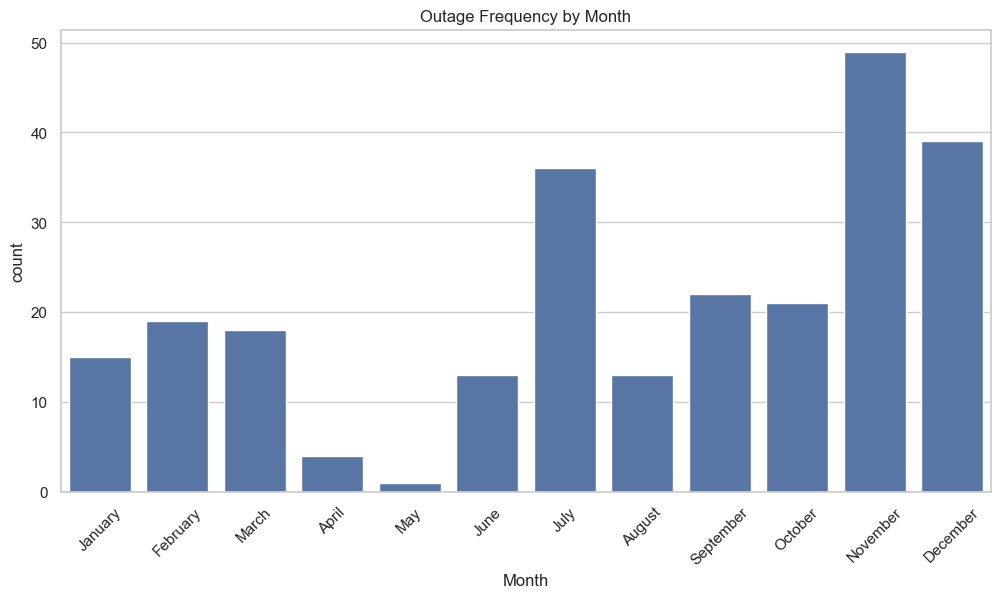

In [14]:
plt.figure(figsize=(12, 6))
order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
         'September', 'October', 'November', 'December']
sns.countplot(data=df, x='Month', order=order)
plt.title('Outage Frequency by Month')
plt.xticks(rotation=45)
plt.show()